In [1]:
from typing_extensions import TypedDict
from typing import Literal
from langgraph.graph import START, END, StateGraph
from IPython.display import Image
import random

#### State

In [10]:
class TypeDictState(TypedDict):
    name: str
    game: Literal["cricket", "badminton"]

#### Nodes

In [15]:
def play_game(state: TypeDictState):
    print("-- Play game note has been called --")
    return {"name": state['name'] + " want to play"}

def cricket(state: TypeDictState):
    print("-- Cricket node has been called --")
    return {"game": "Cricket"}

def badminton(state: TypeDictState):
    print("-- badminton game has been called --")
    return {"game": "badminton"}

In [16]:
def decie_paly(state: TypeDictState)->Literal["cricket", "badminton"]:
    if random.random() < 0.5:
        return "cricket"
    else:
        return "badminton"

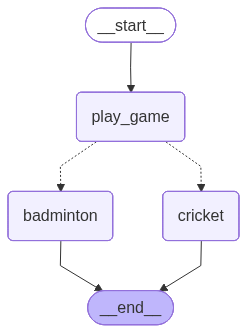

In [17]:
# Build graph
graph = StateGraph(TypeDictState)

# Node
graph.add_node("play_game", play_game)
graph.add_node("badminton", badminton)
graph.add_node("cricket", cricket)

# Edges
graph.add_edge(START, "play_game")
graph.add_conditional_edges("play_game", decie_paly)
graph.add_edge("cricket", END)
graph.add_edge("badminton", END)

# Compile graph
graph_builder = graph.compile()

# Display the graph
Image(graph_builder.get_graph().draw_mermaid_png())


In [23]:
graph_builder.invoke({"name": "hannan"})

-- Play game note has been called --
-- badminton game has been called --


{'name': 'hannan want to play', 'game': 'badminton'}

In [32]:
# dataclass
from dataclasses import dataclass

@dataclass
class DataClassState:
    name: str
    game: Literal["cricket", "badminton"]

In [46]:
def play_game(state: DataClassState):
    print("-- Play game note has been called --")
    return {"name": state.name}

def cricket(state: DataClassState):
    print("-- Cricket node has been called --")
    return {"game": "Cricket"}

def badminton(state: DataClassState):
    print("-- badminton game has been called --")
    return {"game": "badminton"}

In [47]:
def decie_paly(state: DataClassState)->Literal["cricket", "badminton"]:
    if random.random() < 0.5:
        return "cricket"
    else:
        return "badminton"

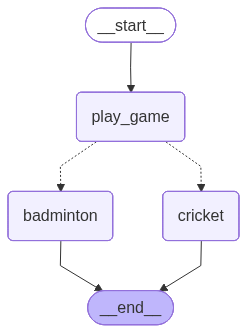

In [48]:
# Build graph
graph = StateGraph(DataClassState)

# Node
graph.add_node("play_game", play_game)
graph.add_node("badminton", badminton)
graph.add_node("cricket", cricket)

# Edges
graph.add_edge(START, "play_game")
graph.add_conditional_edges("play_game", decie_paly)
graph.add_edge("cricket", END)
graph.add_edge("badminton", END)

# Compile graph
graph_builder = graph.compile()

# Display the graph
Image(graph_builder.get_graph().draw_mermaid_png())


In [51]:
graph_builder.invoke(DataClassState(name="Hannna", game="badminton"))

-- Play game note has been called --
-- Cricket node has been called --


{'name': 'Hannna', 'game': 'Cricket'}

In [52]:
graph_builder.invoke(DataClassState(name=1234, game="badminton"))

-- Play game note has been called --
-- Cricket node has been called --


{'name': 1234, 'game': 'Cricket'}

In [53]:
# no error found because typedict and dataclass not enforce 